# Assignment 1

**FROM THE LECTURE**
Solves and simulates a $T$-period labor supply model with consumption-saving ala Keane(2016) but with children. <br>
**Motivated** by the study "Career Costs of Children" by Adda et al. (2017). <br>
**Goal** is to replicate child-penalty event-study graphs ala Kleven et al. (2019).

Letting $n_t\in\{0,1\}$ denote the presence of a child, the **Bellman equation** and the recursive formulation of the model is 

$$
\begin{align}
V_{t}(n_t,a_{t},k_{t})=&\max_{c_{t},h_{t}}\frac{c_{t}^{1+\eta}}{1+\eta}-\beta(n_t)\frac{h_{t}^{1+\gamma}}{1+\gamma}+\rho \mathbb{E}_t[ V_{t+1}(n_{t+1},a_{t+1},k_{t+1})] \\
& \text{s.t.} \\
n_{t+1}= &\begin{cases}
\begin{array}{ll}
n_{t}+1 & \text{with probability } p(n_{t})\\
n_{t} & \text{with probability } 1-p(n_{t})
\end{array}\end{cases} \\
a_{t+1}=&(1+r)(a_{t}+(1-\tau)w_{t}h_{t}-c_{t}) \\
k_{t+1} =&k_{t}+h_{t} 
\end{align}
$$
where wages are endogenous and a child arrive stochastically,
$$
\begin{align}
w_{t}=&w\left(1+\alpha k_{t}\right) \\
p(n_t)=&\begin{cases}
\begin{array}{ll}
p_n & \text{if } n_{t}=0\\
0 &  \text{if } n_{t}=1.
\end{array}\end{cases}
\end{align}
$$

Compared to the previous model of Keane (2016), we now let the dis-utility of work depend on the presence of children,
$$
\beta(n_t) = \beta_0 + \beta_1 \cdot n_t 
$$
such that if $\beta_1=0$ we have the original model.

We will solve this by **backwards induction**, assuming no bequest motive. The last-period problem becomes
$$
\begin{align}
V_{T}(n_T,a_T,k_T)=&\max_{h_{T}}\frac{c_{T}^{1+\eta}}{1+\eta}-\beta(n_T)\frac{h_{T}^{1+\gamma}}{1+\gamma} \\
& \text{s.t.} \\
c_T = &a_{T}+(1-\tau)w_{T}h_{T}.
\end{align}
$$

## Setup

# Consumption-Saving Model

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
# Import the model class
from DynLaborFertModel import DynLaborFertModelClass

## 1.a

In [ ]:
event_grid = np.arange(-8, 9)   # event-tid

# --- event-study-profil: % timer ift. perioden før fødsel (t=-1) ---
def event_study(sim, par):
    birth = np.zeros(sim.n.shape, dtype=np.int_)
    birth[:,1:] = (sim.n[:,1:] - sim.n[:,:-1]) > 0
    periods = np.tile(np.arange(par.simT), (par.simN,1))
    time_of_birth = np.max(periods * birth, axis=1)
    time_of_birth[time_of_birth==0] = -1000          # får aldrig barn
    time_of_birth = np.transpose(np.tile(time_of_birth, (par.simT,1)))
    time_since_birth = periods - time_of_birth
    event_hours = np.array([np.mean(sim.h[time_since_birth==e]) for e in event_grid])
    return (event_hours - event_hours[event_grid==-1]) / event_hours[event_grid==-1]

# --- løs+simulér for en given beta_1 og returnér faldet ved fødsel ---
def drop_at_birth(beta_1, model):
    model.par.beta_1 = beta_1
    model.solve(); model.simulate()
    return event_study(model.sim, model.par)[event_grid==0][0]

# --- estimation: find beta_1 så faldet rammer -10% (kun ÉN model, alpha=0.3) ---
model = DynLaborFertModelClass(par={'T':10,'r':0.02,'rho':1/1.02,'alpha':0.3})
target = -0.10

def obj(beta_1):
    d = drop_at_birth(beta_1, model)
    print(f"beta_1={beta_1:.4f} -> drop={d:.4f}")
    return d - target

beta_1_hat = brentq(obj, 0.0, 0.5, xtol=1e-4)
print(f"\nEstimeret beta_1 = {beta_1_hat:.4f}")

# --- event-study-plot for den estimerede beta_1 ---
model.par.beta_1 = beta_1_hat
model.solve(); model.simulate()
event_hours_pct = event_study(model.sim, model.par)
print(f"Drop at birth: {event_hours_pct[event_grid==0][0]:.3f}")

fig, ax = plt.subplots()
ax.scatter(event_grid, event_hours_pct)
ax.axhline(y=0, color='gray')
ax.axvline(x=-0.5, color='red')
ax.set(xlabel='Time since birth', ylabel='Hours worked (rel. to -1)', xticks=event_grid);

KeyboardInterrupt: 

## 1.b

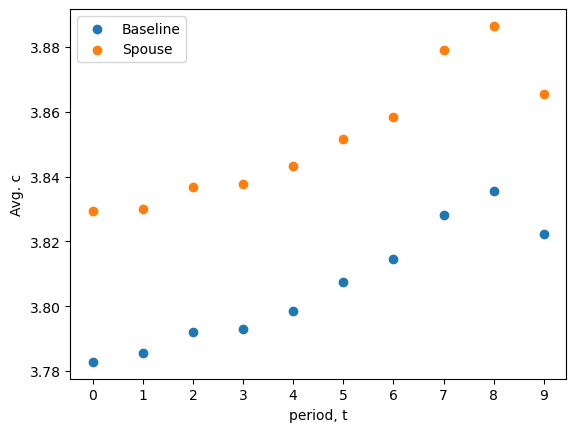

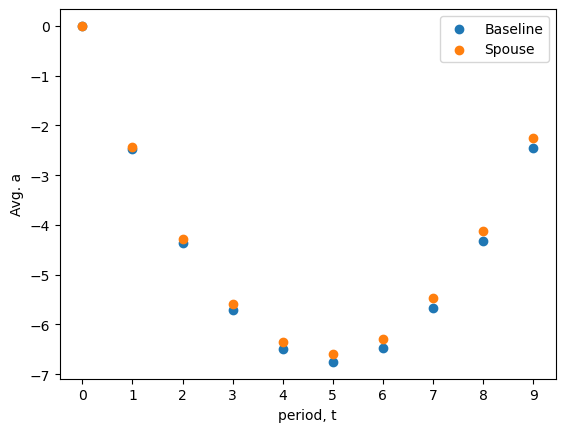

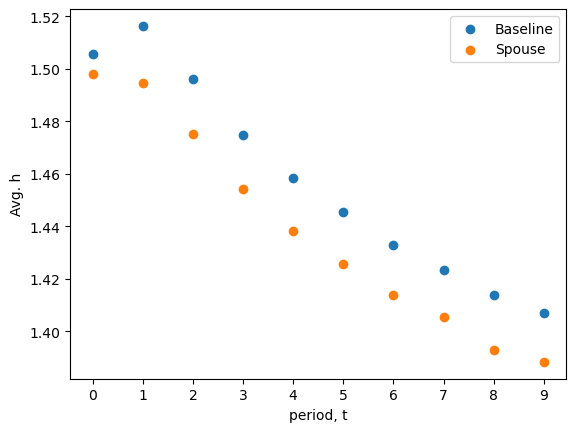

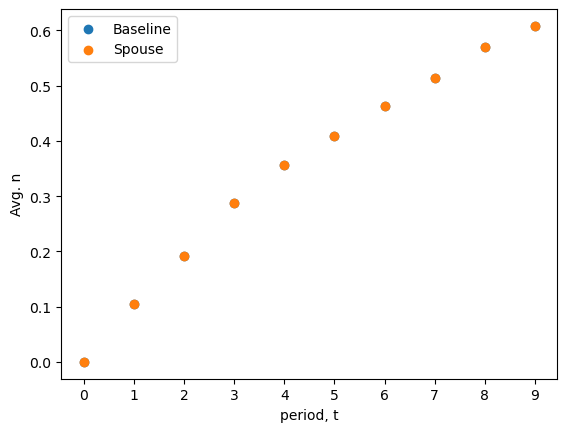

In [ ]:
# baseline
model_base = DynLaborFertModelClass(par={'T':10,'r':0.02,'rho':1/(1.02),'alpha':0.3, 'beta_1': 0.0558, 'y_spouse': 0.0})
model_base.solve()
model_base.simulate()

# spouse model
model_spouse = DynLaborFertModelClass(par={'T':10,'r':0.02,'rho':1/(1.02),'alpha':0.3, 'beta_1': 0.0558, 'y_spouse': 1.0})
model_spouse.solve()
model_spouse.simulate()

# plot comparison
for var in ('c','a','h','n'):
    fig, ax = plt.subplots()
    ax.scatter(range(model_base.par.simT), np.mean(getattr(model_base.sim, var), axis=0), label='Baseline')
    ax.scatter(range(model_spouse.par.simT), np.mean(getattr(model_spouse.sim, var), axis=0), label='Spouse')
    ax.legend()
    ax.set(xlabel='period, t', ylabel=f'Avg. {var}', xticks=range(model_base.par.simT))

## 1.c


In [ ]:
# baseline
model_base = DynLaborFertModelClass(par={'T':10,'r':0.02,'rho':1/(1.02),'alpha':0.3, 'beta_1': 0.0558, 'y_spouse': 0.0, 'theta': 0.0})
model_base.solve()
model_base.simulate()

# childcare cost model
model_theta = DynLaborFertModelClass(par={'T':10,'r':0.02,'rho':1/(1.02),'alpha':0.3, 'beta_1': 0.0558, 'y_spouse': 0.0, 'theta': 0.05})
model_theta.solve()
model_theta.simulate()

# plot comparison
for var in ('c','a','h','n'):
    fig, ax = plt.subplots()
    ax.scatter(range(model_base.par.simT), np.mean(getattr(model_base.sim, var), axis=0), label='Baseline')
    ax.scatter(range(model_theta.par.simT), np.mean(getattr(model_theta.sim, var), axis=0), label='Childcare cost')
    ax.legend()
    ax.set(xlabel='period, t', ylabel=f'Avg. {var}', xticks=range(model_base.par.simT))

def marshall_elasticity(par_dict, dlnw=0.01):
    m = DynLaborFertModelClass(par=par_dict)
    m.solve(); m.simulate()
    h0 = m.sim.h.mean()
    m.par.w_vec = m.par.w_vec*(1+dlnw)   # løn +1%
    m.solve(); m.simulate()
    h1 = m.sim.h.mean()
    return ((h1-h0)/h0)/dlnw

base_par  = {'T':10,'r':0.02,'rho':1/1.02,'alpha':0.3,'beta_1':0.0558,'y_spouse':0.0,'theta':0.0}
theta_par = {**base_par, 'theta':0.05}
print(f"Marshall elasticity — baseline: {marshall_elasticity(base_par):.3f}")
print(f"Marshall elasticity — childcare: {marshall_elasticity(theta_par):.3f}")

## 1.e

In [ ]:
from DynLaborFertModel import DynLaborFertModelClass

## 1.e
model_base = DynLaborFertModelClass(par={'T':10,'r':0.02,'rho':1/1.02,'alpha':0.3,
                                          'beta_1':0.0558,'y_spouse':0.0,'theta':0.0,'p_spouse':1.0})
model_base.solve(); model_base.simulate()

model_spouse_stoch = DynLaborFertModelClass(par={'T':10,'r':0.02,'rho':1/1.02,'alpha':0.3,
                                                 'beta_1':0.0558,'y_spouse':1.0,'theta':0.0,'p_spouse':0.8})
model_spouse_stoch.solve(); model_spouse_stoch.simulate()

for var in ('c','a','h','n'):
    fig, ax = plt.subplots()
    ax.scatter(range(model_base.par.simT), np.mean(getattr(model_base.sim,var),axis=0), label='Baseline')
    ax.scatter(range(model_spouse_stoch.par.simT), np.mean(getattr(model_spouse_stoch.sim,var),axis=0), label='Stochastic spouse')
    ax.legend(); ax.set(xlabel='period, t', ylabel=f'Avg. {var}', xticks=range(model_base.par.simT))

KeyboardInterrupt: 